<a href="https://colab.research.google.com/github/nkreuzer26/Milestone_2/blob/main/NK_Milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook attempts to replicate the findings from a study estimating the economic impact of cartel violence in Colombia. The original paper uses the Synthetic Control Method (SCM) to construct a counterfactual version of Colombia from a weighted combination of similar countries. By comparing Colombia’s actual GDP per capita to this synthetic control, the study estimates how economic growth changed after cartel violence escalated in the mid-1970s. Following the same approach used in the paper, this replication recreates the dataset, builds the donor pool, and estimates the synthetic control model to reproduce the main results.

# Screening potential donor countries by GDP  

I started by loading the Maddison Project Database and using 1975 GDP per capita to screen potential comparison countries. Following the original study, countries in a middle-income range are more plausible donors for Colombia than very poor or very rich countries. Below I filter countries by their 1975 GDP to narrow the initial set of candidate countries for the donor pool used to recreate the synthetic colombia.

In [1]:
import pandas as pd

# Load the Maddison Project Database
maddison_data = pd.read_excel("mpd2023_web (2).xlsx", sheet_name="Full data")

# Keep only observations with GDP per capita data for 1975
gdp_1975 = (
    maddison_data.loc[maddison_data["year"] == 1975, ["country", "year", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)

# Rank countries by 1975 GDP per capita using percentile ranks
gdp_1975["gdp_percentile_rank"] = gdp_1975["gdppc"].rank(pct=True)

# Exclude the richest 30% and poorest 30% of countries,
# keeping the middle 40% of the global income distribution, bc Colombia is in the 57th percentile.
middle_income_countries = gdp_1975[
    (gdp_1975["gdp_percentile_rank"] > 0.30) &
    (gdp_1975["gdp_percentile_rank"] < 0.70)
].copy()

# Sort the remaining countries by GDP per capita
middle_income_countries = middle_income_countries.sort_values("gdppc", ascending=False)

print(f"Countries after income filter: {len(middle_income_countries)}")
middle_income_countries[["country", "gdppc", "gdp_percentile_rank"]]

Countries after income filter: 62


,country,gdppc,gdp_percentile_rank
114024,Syrian Arab Republic,8878.0,0.699346
124112,Uruguay,8563.0,0.692810
107816,Serbia,8498.0,0.686275
76776,TFYR of Macedonia,8064.0,0.679739
76000,Mexico,8011.0,0.673203
...,...,...,...
69016,Saint Lucia,2428.0,0.326797
52720,Indonesia,2386.0,0.320261
36424,Egypt,2265.0,0.313725
81432,Mozambique,2238.0,0.307190


### Reconstructing the donor pool

To reconstruct the donor pool, I next compared my Maddison-based middle-income screen to the country list reported in Table A.1 of the appendix. My initial filter retained 62 countries, while the paper reports 53 at this stage. Because the appendix doesn't fully explain the preliminary exclusions applied before this table, I used Table A.1 as the benchmark and removed countries that appeared in my table but not in the paper’s reported candidate pool. The code below shows the removals and the rationale for each one.

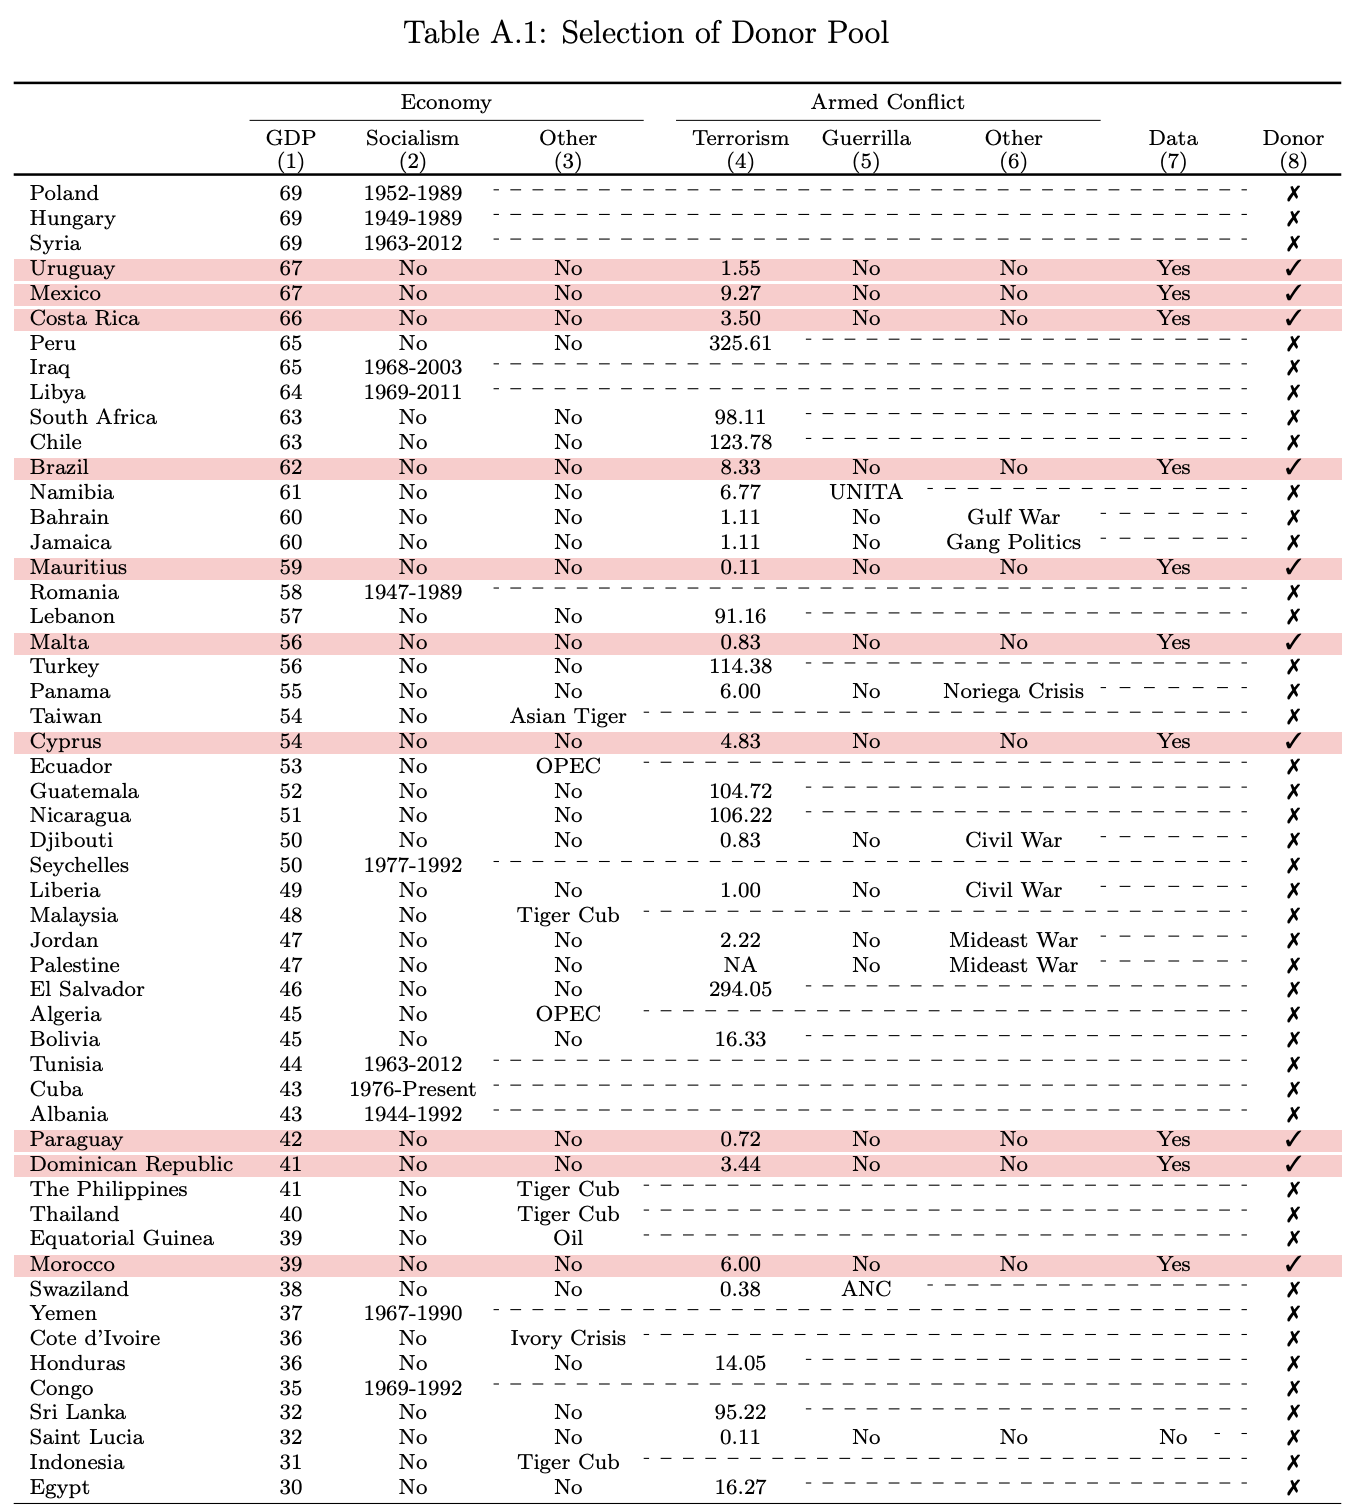

In [2]:
# Countries listed in Table A.1 of the paper before later donor-pool exclusions
table_a1_countries = [
    "Poland", "Hungary", "Syria", "Uruguay", "Mexico", "Costa Rica", "Peru", "Iraq", "Libya",
    "South Africa", "Chile", "Brazil", "Namibia", "Bahrain", "Jamaica", "Mauritius", "Romania",
    "Lebanon", "Malta", "Turkey", "Panama", "Taiwan", "Cyprus", "Ecuador", "Guatemala",
    "Nicaragua", "Djibouti", "Seychelles", "Liberia", "Malaysia", "Jordan", "Palestine",
    "El Salvador", "Algeria", "Bolivia", "Tunisia", "Cuba", "Albania", "Paraguay",
    "Dominican Republic", "Philippines", "Thailand", "Equatorial Guinea", "Morocco",
    "Swaziland", "Yemen", "Cote d’Ivoire", "Honduras", "Congo", "Sri Lanka", "Saint Lucia",
    "Indonesia", "Egypt"
]

# Compare the countries retained by the Maddison-based GDP filter
# to the countries explicitly reported in Table A.1 of the appendix
reconstructed_countries = set(middle_income_countries["country"])
appendix_countries = set(table_a1_countries)

# Identify countries that appear in the Maddison-based reconstruction
# but do not appear in the paper's reported appendix list
extra_countries = sorted(reconstructed_countries - appendix_countries)

# Document the countries removed in order to align the reconstruction
# with the candidate pool reported by the authors in Table A.1
removal_reasons = {
    "Colombia": "Treated country, so it cannot be part of the donor pool",
    "Bosnia and Herzegovina": "Post-Yugoslav successor state not treated as an independent unit in the study period",
    "Former Yugoslavia": "Historical aggregate not aligned with the country units used in the appendix",
    "Montenegro": "Post-Yugoslav successor state not used in the appendix country list",
    "Serbia": "Post-Yugoslav successor state not used in the appendix country list",
    "TFYR of Macedonia": "Post-Yugoslav successor state not used in the appendix country list",
    "Mozambique": "Likely excluded because of missing predictor data needed for SCM",
    "Oman": "Likely excluded because of missing predictor data needed for SCM",
    "Sao Tome and Principe": "Likely excluded because of missing predictor data needed for SCM",
    "Zimbabwe": "Likely excluded because of incomplete predictor coverage",
    "Republic of Korea": "Not included in the appendix candidate pool, likely because it is not comparable to Colombia in the study design"
}

# Remove the extra countries so the reconstructed set matches the appendix more closely
aligned_middle_income_countries = middle_income_countries[
    ~middle_income_countries["country"].isin(removal_reasons.keys())
].copy()

# Create a table documenting the removals used to recreate the reconstructed pool
removal_table = pd.DataFrame({
    "country": list(removal_reasons.keys()),
    "reason_removed": list(removal_reasons.values())
})

print(f"Countries from Maddison-based middle-income filter: {len(middle_income_countries)}")
print(f"Countries listed in Table A.1: {len(table_a1_countries)}")
print(f"Extra countries removed to align with the appendix: {len(extra_countries)}")
print(f"Countries remaining after alignment: {len(aligned_middle_income_countries)}")

removal_table

Countries from Maddison-based middle-income filter: 62
Countries listed in Table A.1: 53
Extra countries removed to align with the appendix: 16
Countries remaining after alignment: 51


,country,reason_removed
0,Colombia,"Treated country, so it cannot be part of the d..."
1,Bosnia and Herzegovina,Post-Yugoslav successor state not treated as a...
2,Former Yugoslavia,Historical aggregate not aligned with the coun...
3,Montenegro,Post-Yugoslav successor state not used in the ...
4,Serbia,Post-Yugoslav successor state not used in the ...
5,TFYR of Macedonia,Post-Yugoslav successor state not used in the ...
6,Mozambique,Likely excluded because of missing predictor d...
7,Oman,Likely excluded because of missing predictor d...
8,Sao Tome and Principe,Likely excluded because of missing predictor d...
9,Zimbabwe,Likely excluded because of incomplete predicto...


### Reconstructing the 10 country donor pool
After identifying countries with GDP levels broadly comparable to Colombia, the study applied additional screening criteria to construct the final donor pool from the 52-country list. The goal of was to ensure that potential comparison countries resemble Colombia both in income level and in political stability, security conditions, and economic structure prior to the treatment period (treatment period = uptick in cartel violence).

Following the appendix, countries are excluded if they exhibit characteristics that would make them poor counterfactual comparisons. These include socialist or highly state-directed economies, countries experiencing high levels of terrorism (more than 10 attacks per year), the presence of guerrilla movements or other armed conflicts, and cases where other major economic disruptions were occurring. Countries are also removed when the macroeconomic predictor variables required for the synthetic control model are unavailable.

Applying these criteria reduces the candidate set to a smaller group of countries that are plausibly comparable to Colombia. These remaining countries form the donor pool from which the synthetic control is derived.

In [3]:
# Make the appendix screening table a DataFrame.
# Each indicator corresponds to one exclusion criterion used by the study
# to narrow the candidate pool after the initial GDP-based screening step.
appendix_screening = pd.DataFrame({
    "country": [
        "Poland", "Hungary", "Syria", "Uruguay", "Mexico", "Costa Rica", "Peru", "Iraq", "Libya",
        "South Africa", "Chile", "Brazil", "Namibia", "Bahrain", "Jamaica", "Mauritius", "Romania",
        "Lebanon", "Malta", "Turkey", "Panama", "Taiwan", "Cyprus", "Ecuador", "Guatemala",
        "Nicaragua", "Djibouti", "Seychelles", "Liberia", "Malaysia", "Jordan", "Palestine",
        "El Salvador", "Algeria", "Bolivia", "Tunisia", "Cuba", "Albania", "Paraguay",
        "Dominican Republic", "Philippines", "Thailand", "Equatorial Guinea", "Morocco",
        "Swaziland", "Yemen", "Cote d’Ivoire", "Honduras", "Congo", "Sri Lanka", "Saint Lucia",
        "Indonesia", "Egypt"
    ]
})

# Indicator for socialist or highly state-directed economies.
# The paper excludes these countries because their economic systems
# are not considered comparable to Colombia's pre-treatment context.
appendix_screening["socialism_state"] = [
    1, 1, 1, 0, 0, 0, 0, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 1,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 1, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 0,
    0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
    0, 0
]

# Indicator for countries experiencing high levels of terrorism
# (more than 10 attacks per year), which the paper treats as making
# them poor counterfactual comparisons for Colombia.
appendix_screening["terrorism_gt_10"] = [
    0, 0, 0, 0, 0, 0, 1, 0, 0,
    1, 1, 0, 0, 0, 0, 0, 0,
    1, 0, 1, 0, 0, 0, 0, 1,
    1, 0, 0, 0, 0, 0, 0,
    1, 0, 1, 0, 0, 0, 0,
    0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
    0, 1
]

# Indicator for the presence of guerrilla movements,
# another exclusion criterion used to avoid countries facing
# internal security conditions too similar to or confounded with Colombia's conflict.
appendix_screening["guerrilla_presence"] = [
    0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 1, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
    0, 0
]

# Indicator for other forms of armed conflict.
# These countries are excluded because major conflict could independently affect GDP,
# making them unsuitable building blocks for a synthetic Colombia.
appendix_screening["other_armed_conflict"] = [
    0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 0, 0,
    0, 0, 0, 1, 0, 0, 0, 0,
    0, 1, 0, 1, 0, 1, 1,
    0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
    0, 0
]

# Indicator for other major economic reasons the appendix identifies
# as grounds for exclusion from the donor pool.
appendix_screening["other_economic_reason"] = [
    0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 0, 0,
    0, 0, 0, 1, 1, 0, 1, 0,
    0, 0, 0, 0, 1, 0, 0,
    0, 1, 0, 0, 0, 0, 0,
    0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 0
]

# Indicator for whether the macroeconomic data needed for the synthetic control model
# are available for that country.
appendix_screening["data_available"] = [
    1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
    1, 1
]

# A country is retained in the final donor pool only if it is not flagged
# on any exclusion criterion and has the required data available.
appendix_screening["included_final_pool"] = (
    (appendix_screening["socialism_state"] == 0) &
    (appendix_screening["terrorism_gt_10"] == 0) &
    (appendix_screening["guerrilla_presence"] == 0) &
    (appendix_screening["other_armed_conflict"] == 0) &
    (appendix_screening["other_economic_reason"] == 0) &
    (appendix_screening["data_available"] == 1)
)

# Keep only the countries that satisfy all appendix screening criteria.
final_donor_pool = appendix_screening[appendix_screening["included_final_pool"]].copy()

# Display the countries that remain after all appendix-based exclusions.
final_donor_pool[["country", "included_final_pool"]]


# Construct the list of countries used in the analysis.
# The synthetic control model will combine the donor countries
# to construct a counterfactual GDP path for Colombia.
donor_countries = final_donor_pool["country"].tolist()
countries_of_interest = donor_countries + ["Colombia"]

# Restrict the Maddison dataset to the countries used in the analysis
analysis_panel = maddison_data[
    maddison_data["country"].isin(countries_of_interest)
].copy()

# Restrict the time window to the study period used in the paper
analysis_panel = analysis_panel[
    (analysis_panel["year"] >= 1950) &
    (analysis_panel["year"] <= 1993)
].copy()

# Convert the panel dataset to wide format so that each country
# becomes a column and each row corresponds to a year.
# This structure is required for the synthetic control procedure.
gdp_panel = analysis_panel.pivot(
    index="year",
    columns="country",
    values="gdppc"
)


donor_countries = final_donor_pool["country"].tolist()
print("Countries meeting all appendix screening criteria:")
print(donor_countries)

Countries meeting all appendix screening criteria:
['Uruguay', 'Mexico', 'Costa Rica', 'Brazil', 'Mauritius', 'Malta', 'Cyprus', 'Paraguay', 'Dominican Republic', 'Morocco']


# Creation of Predictor Variables

Now that the donor countries are identified, the next step is to determine how much each country should contribute to the synthetic version of Colombia. In the synthetic control method, the counterfactual is constructed as a weighted combination of donor countries instead of an average. This allows the algorithm to select the mix of countries whose economic characteristics most closely resemble Colombia before the treatment period.

To accomplish this the method organizes information about the treated unit and the donor countries into matrices of predictor variables. These predictors summarize economic characteristics observed prior to the onset of cartel violence. Examples include measures such as human capital, investment rates, inflation, exchange rates, and agricultural productivity. By comparing these variables across countries, the algorithm identifies the set of donor weights that best reproduce Colombia’s pre-treatment economic profile.

Basically, countries that more closely resemble Colombia across these predictors will receive larger weights in the synthetic control, while less similar countries receive little or no weight. One of the most important predictors used in this process is GDP per capita itself, which helps ensure that the synthetic control closely matches Colombia’s economic trajectory prior to 1976.

# Predictor Variable #1: GDP per Capita

In [4]:
# Make the GDP predictor used in the synthetic control model.
# Following the paper GDP per capita is averaged over the pre-treatment
# period (1961–1975). This helps verufy that the synthetic control
# reproduces Colombia's economic level prior to the uptick of cartel violence.

pre_treatment_period = analysis_panel[
    (analysis_panel["year"] >= 1961) &
    (analysis_panel["year"] <= 1975)
].copy()

# Calculate the average GDP per capita for each country during the pre-treatment period
gdp_predictor = (
    pre_treatment_period
    .groupby("country")["gdppc"]
    .mean()
    .reset_index()
)

# Convert the predictor into wide format so each country becomes a column
# and the row represents the GDP predictor used by the SCM algorithm
predictor_matrix = gdp_predictor.set_index("country").T

# Label the predictor row clearly
predictor_matrix.index = ["GDP_avg_1961_1975"]

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.4,4767.133333,5647.466667,5747.2,2512.133333,3441.2,5214.133333,6379.4,2451.866667,2795.933333,7733.666667


# Predictor Variable #2: Human Capital Index

Another predictor included in the synthetic control model is the Human Capital Index from the Penn World Table (PWT). This variable is designed to represent the productivity of a country’s workforce by incorporating information on educational attainment and returns to schooling. It represents the average level of skills and knowledge of the labor force.

Including human capital is important because economic growth depends on the quality of human resources available for production. Countries with similar human capital levels are therefore more likely to follow comparable economic trajectories. As with GDP, the study summarizes this variable by averaging it over the pre-treatment period.

In [5]:
# Load Penn World Table data and keep only the countries included in the analysis.
# The Human Capital Index is taken from PWT and averaged over the pre-treatment period
# so that each country is represented by its typical level of workforce human capital
# before cartel violence intensified in Colombia.
pwt_data = pd.read_excel("pwt110.xlsx", sheet_name="Data")

pwt_analysis = pwt_data[pwt_data["country"].isin(countries_of_interest)].copy()

# Restrict to the pre-treatment period used to construct the predictor matrix
pwt_pre_treatment = pwt_analysis[
    (pwt_analysis["year"] >= 1961) &
    (pwt_analysis["year"] <= 1975)
].copy()

# Calcuulate each country's average Human Capital Index from 1961 to 1975
human_capital_predictor = (
    pwt_pre_treatment
    .groupby("country")["hc"]
    .mean()
    .reset_index()
)

# Reshape to wide format so the predictor can be added as a new row
# in the synthetic control predictor matrix
human_capital_row = human_capital_predictor.set_index("country").T
human_capital_row.index = ["HumanCapital_avg_1961_1975"]

# Add the human capital predictor to the existing predictor matrix
predictor_matrix = pd.concat([predictor_matrix, human_capital_row])

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488


# Predictor Variable #3: Inflation Rate

They next included in the model the inflation rate of consumer prices, obtained from the Our World in Data macroeconomic dataset. This measures the annual percentage change in the consumer price index (CPI), representing how quickly the general price for goods and services is rising in an economy. Consumer price inflation is widely used as an indicator of macroeconomic stability and the effectiveness of monetary policy.

Including inflation helps validate that the synthetic control is constructed from countries that experienced similar macroeconomic conditions prior to the treatment period (in this case inflation). As with the other predictors, inflation is summarized by averaging values over the pre-treatment window (1961–1975).

In [6]:
# Load consumer price inflation data from Our World in Data.
# Variable measures the annual percent change in consumer prices
# and is included to capture macroeconomic stability before the treatment period.
inflation_data = pd.read_csv("inflation-of-consumer-prices.csv")

# Standardize column names
inflation_data = inflation_data.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Inflation, consumer prices (annual %)": "inflation"
})

# Keep only Colombia and the countries in the donor pool
inflation_analysis = inflation_data[
    inflation_data["country"].isin(countries_of_interest)
].copy()

# Restrict to the pre-treatment period used to construct predictors.
# The study uses pre-1976 averages so donor weights are based only on
# characteristics observed before cartel violence escalated
inflation_pre_treatment = inflation_analysis[
    (inflation_analysis["year"] >= 1961) &
    (inflation_analysis["year"] <= 1975)
].copy()

# Calculate each country's average consumer price inflation over 1961–1975
inflation_predictor = (
    inflation_pre_treatment
    .dropna(subset=["inflation"])
    .groupby("country")["inflation"]
    .mean()
    .reindex(countries_of_interest)
)

# Reshape to wide format so inflation becomes one row
# in the overall predictor matrix
inflation_row = inflation_predictor.to_frame().T
inflation_row.index = ["Inflation_avg_1961_1975"]

# Add inflation to the predictor matrix
predictor_matrix = pd.concat([predictor_matrix, inflation_row])

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488
Inflation_avg_1961_1975,NaN,13.641057,6.253807,3.247363,5.020367,3.138413,6.826316,5.897870,4.029458,6.161575,55.682482


# Predictor Variable #4: Schooling
Another predictor included in the model is the average years of schooling in the adult population. This measures the average amount of formal education completed by adults in a country and serves as a proxy for the overall educational attainment of the workforce.

Educational attainment is linked to labor productivity, technological adoption, and longterm economic growth. Countries with similar schooling levels are therefore more likely to share comparable economic development paths. Including this helps ensure that the synthetic control also captures the educational characteristics of its labor force. As with the other predictors, the variable is averaged over the pre-treatment period (1961–1975).

In [7]:
# Load the schooling dataset and extract the average years of schooling variable.
schooling_data = pd.read_excel(
    "BL2013_MF2599_v2.2.xls",
    sheet_name="Sheet1",
    header=7
)

# Forward-fill country names because the source file uses merged country labels
schooling_data["Country"] = schooling_data["Country"].ffill()
schooling_data = schooling_data[schooling_data["Country"].notna()].copy()

# Standardize column names and keep only the variables needed for the predictor
schooling_data = schooling_data.rename(columns={
    "Country": "country",
    "Year": "year",
    "Avg. Years of Total Schooling": "school_years"
})[["country", "year", "school_years"]]

# Change country names so they match the naming used in the other datasets
schooling_data["country"] = schooling_data["country"].replace({
    "Dominican Rep.": "Dominican Republic"
})

# Keep only Colombia and the donor countries included in the analysis
schooling_analysis = schooling_data[
    schooling_data["country"].isin(countries_of_interest)
].copy()

# Restrict to the pre-treatment period so the predictor is based only on
# educational attainment observed before cartel violence escalated
schooling_pre_treatment = schooling_analysis[
    (schooling_analysis["year"] >= 1961) &
    (schooling_analysis["year"] <= 1975)
].copy()

# Calculate each country's average years of schooling over 1961–1975
schooling_predictor = (
    schooling_pre_treatment
    .groupby("country")["school_years"]
    .mean()
    .reindex(countries_of_interest)
)

# Reshape to wide format so schooling becomes one row in the predictor matrix
schooling_row = schooling_predictor.to_frame().T
schooling_row.index = ["Schooling_avg_1961_1975"]

# Add the schooling predictor to the overall predictor matrix
predictor_matrix = pd.concat([predictor_matrix, schooling_row])

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488
Inflation_avg_1961_1975,NaN,13.641057,6.253807,3.247363,5.020367,3.138413,6.826316,5.897870,4.029458,6.161575,55.682482
Schooling_avg_1961_1975,2.893333,3.440000,3.986667,5.253333,3.036667,5.210000,3.706667,2.920000,0.633333,3.733333,5.193333


# Predictor Variable #5: Investment
Another predictor used in the synthetic control model is the investment share of GDP. This measures the proportion of a country’s economic output devoted to investment in physical capital like machinery, infrastructure, and equipment. Investment rates are tied to capital accumulation and are an important determinant of economic growth and development.

The study includes investment share for two shorter periods: 1960–1965 and 1970–1975. These windows are used because consistent data are not available for the entire pre-treatment period across all countries. Including investment rates helps validate that the synthetic control is made from countries with similar patterns of capital formation prior to the treatment.

In [8]:
# Load the data used for the investment share predictors.
# The file is organized by country in SHCODE order, with investment share
# reported for five-year periods instead of annual reports.
investment_columns = [
    "gdpsh550", "gdpsh555", "gdpsh560", "gdpsh565", "gdpsh570", "gdpsh575",
    "gdpsh580", "gdpsh585", "gdpsh589", "gdpsh590",
    "grsh51", "grsh52", "grsh53", "grsh54", "grsh55", "grsh56", "grsh56a",
    "invsh51", "invsh52", "invsh53", "invsh54", "invsh55", "invsh56"
]

investment_data = pd.read_csv(
    "gdpsh5.prn",
    sep=r"\s+",
    header=None,
    names=investment_columns,
    na_values="NA"
)

# Add SHCODE because the raw file is ordered by country code
investment_data["SHCODE"] = range(1, len(investment_data) + 1)

# Map the treated unit and donor countries to their SHCODE values
# These are the countries that remain after the appendix-based donor pool screening
shcode_to_country = {
    28: "Mauritius",
    29: "Morocco",
    51: "Costa Rica",
    53: "Dominican Republic",
    60: "Mexico",
    69: "Brazil",
    71: "Colombia",
    74: "Paraguay",
    77: "Uruguay",
    109: "Cyprus",
    120: "Malta"
}

target_shcodes = list(shcode_to_country.keys())

# Keep only Colombia and the donor countries used in the synthetic control analysis
investment_analysis = investment_data[
    investment_data["SHCODE"].isin(target_shcodes)
].copy()

investment_analysis["country"] = investment_analysis["SHCODE"].map(shcode_to_country)

# The dataset reports investment share as five-year period averages
# Use the period centered on the early 1960s (invsh51)
# and the period centered on the early 1970s (invsh53) to approximate
# investment conditions over 1960–1965 and 1970–1975.
investment_1960_1965 = (
    investment_analysis
    .set_index("country")["invsh51"]
    .reindex(countries_of_interest)
)

investment_1970_1975 = (
    investment_analysis
    .set_index("country")["invsh53"]
    .reindex(countries_of_interest)
)

# Add both investment-share predictors as separate rows in the predictor matrix.
# They are kept as distinct rows because the study uses two investment periods
predictor_matrix.loc["Investment_1960_1965"] = investment_1960_1965
predictor_matrix.loc["Investment_1970_1975"] = investment_1970_1975

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488
Inflation_avg_1961_1975,NaN,13.641057,6.253807,3.247363,5.020367,3.138413,6.826316,5.897870,4.029458,6.161575,55.682482
Schooling_avg_1961_1975,2.893333,3.440000,3.986667,5.253333,3.036667,5.210000,3.706667,2.920000,0.633333,3.733333,5.193333
Investment_1960_1965,0.199240,0.181680,0.147280,0.324700,0.101760,0.268880,0.132760,0.157440,0.072760,0.072340,0.172720
Investment_1970_1975,0.234620,0.175480,0.178720,0.320640,0.179360,0.263180,0.128760,0.187360,0.106780,0.112680,0.154380


# Predictor Variable #6: Real Exchange Rate
The model also includes the real exchange rate as a predictor. The real exchange rate is the value of a country’s currency relative to others after adjusting for price levels, making it useful for comparing international competitiveness across countries. Changes in the real exchange rate can influence exports, imports, investment incentives, and the overall structure of economic growth.

Including this variable helps account for countries facing similar external economic conditions before the treatment period. If Colombia and a donor country had very different exchange rate environments, their growth paths could separate for reasons unrelated to cartel violence. As with most of the other predictors, the real exchange rate is summarized using its average value over the pre-treatment period.

In [9]:
# Load the real effective exchange rate (REER) dataset
# REER captures a country's external price competitiveness and is included
# to help match Colombia with donor countries w similar trade conditions
# before cartel violence
reer_data = pd.read_excel(
    "REER_database_ver16Feb2026.xls",
    sheet_name="REER_ANNUAL_65"
)

# Rename the first column to make consistent with the other datasets
reer_data = reer_data.rename(columns={reer_data.columns[0]: "year"})

# Keep only the REER series for Colombia and the countries in the donor pool
reer_columns = [
    "year",
    "REER_65_BR",
    "REER_65_CO",
    "REER_65_CR",
    "REER_65_CY",
    "REER_65_DO",
    "REER_65_MT",
    "REER_65_MU",
    "REER_65_MX",
    "REER_65_MA",
    "REER_65_PY",
    "REER_65_UY"
]

reer_analysis = reer_data[reer_columns].copy()

# Average REER over the pre-treatment period so each country is represented
# by typical exchange rate prior to 1976
reer_predictor = (
    reer_analysis[
        (reer_analysis["year"] >= 1961) &
        (reer_analysis["year"] <= 1975)
    ]
    .drop(columns="year")
    .mean()
)

# Replace names with full country names
reer_predictor.index = [
    "Brazil",
    "Colombia",
    "Costa Rica",
    "Cyprus",
    "Dominican Republic",
    "Malta",
    "Mauritius",
    "Mexico",
    "Morocco",
    "Paraguay",
    "Uruguay"
]

# Reorder the predictor with the same country order used in the matrix
reer_predictor = reer_predictor.reindex(countries_of_interest)

# Add the REER predictor as a new row in the predictor matrix
predictor_matrix.loc["REER_avg_1961_1975"] = reer_predictor

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488
Inflation_avg_1961_1975,NaN,13.641057,6.253807,3.247363,5.020367,3.138413,6.826316,5.897870,4.029458,6.161575,55.682482
Schooling_avg_1961_1975,2.893333,3.440000,3.986667,5.253333,3.036667,5.210000,3.706667,2.920000,0.633333,3.733333,5.193333
Investment_1960_1965,0.199240,0.181680,0.147280,0.324700,0.101760,0.268880,0.132760,0.157440,0.072760,0.072340,0.172720
Investment_1970_1975,0.234620,0.175480,0.178720,0.320640,0.179360,0.263180,0.128760,0.187360,0.106780,0.112680,0.154380
REER_avg_1961_1975,85.379069,138.263872,208.866294,136.513850,137.541602,142.059192,127.456156,98.664753,156.510525,165.991951,90.295721


# Predictor Variable #7: Agricultural Total Factor Productivity
The final predictor included in the model is Agricultural Total Factor Productivity (TFP). This measures the efficiency with which inputs like land, labor, capital, and materials are used in agricultural production. TFP represents improvements in technology, farming practices, and overall productivity within the agricultural sector.

Agriculture was a significant component of many developing economies during the study period, including Colombia. Differences in agricultural productivity can therefore influence overall economic performance and structural transformation. Including Agricultural TFP helps ensure that the synthetic control is constructed from countries with similar levels of productivity in the agriculture sector. just like the other predictors, the variable is summarized using its average value over the pre-treatment period (1961–1975).

In [10]:
# Load the agricultural total factor productivity dataset.
agricultural_tfp_data = pd.read_excel(
    "AgTFPInternational2023.xlsx",
    sheet_name="AG TFP",
    header=2
)

# Keep only Colombia and the donor countries included in the analysis
agricultural_tfp_analysis = agricultural_tfp_data[
    agricultural_tfp_data["ISO3"].isin([
        "BRA", "COL", "CRI", "CYP", "DOM",
        "MLT", "MUS", "MEX", "MAR", "PRY", "URY"
    ])
].copy()

# Avrage agricultural TFP over the pre-treatment period 1961–1975
pre_treatment_years = list(range(1961, 1976))
agricultural_tfp_predictor = agricultural_tfp_analysis[pre_treatment_years].mean(axis=1)

# Use country names as the index so the predictor aligns with the rest of the matrix
agricultural_tfp_predictor.index = agricultural_tfp_analysis["Country/territory"].values
agricultural_tfp_predictor = agricultural_tfp_predictor.reindex(countries_of_interest)

# Add aggricultural TFP as the final predictor row
predictor_matrix.loc["TFP_avg_1961_1975"] = agricultural_tfp_predictor

predictor_matrix

country,Brazil,Colombia,Costa Rica,Cyprus,Dominican Republic,Malta,Mauritius,Mexico,Morocco,Paraguay,Uruguay
GDP_avg_1961_1975,4553.400000,4767.133333,5647.466667,5747.200000,2512.133333,3441.200000,5214.133333,6379.400000,2451.866667,2795.933333,7733.666667
HumanCapital_avg_1961_1975,1.465281,1.664571,1.679046,1.928727,1.476291,1.884269,1.489677,1.705335,1.078723,1.621795,1.902488
Inflation_avg_1961_1975,NaN,13.641057,6.253807,3.247363,5.020367,3.138413,6.826316,5.897870,4.029458,6.161575,55.682482
Schooling_avg_1961_1975,2.893333,3.440000,3.986667,5.253333,3.036667,5.210000,3.706667,2.920000,0.633333,3.733333,5.193333
Investment_1960_1965,0.199240,0.181680,0.147280,0.324700,0.101760,0.268880,0.132760,0.157440,0.072760,0.072340,0.172720
Investment_1970_1975,0.234620,0.175480,0.178720,0.320640,0.179360,0.263180,0.128760,0.187360,0.106780,0.112680,0.154380
REER_avg_1961_1975,85.379069,138.263872,208.866294,136.513850,137.541602,142.059192,127.456156,98.664753,156.510525,165.991951,90.295721
TFP_avg_1961_1975,35.065382,62.731685,49.015369,78.874629,66.554167,33.960905,113.889638,37.898489,74.325225,79.742276,103.925492


# Prepare Donor Pool for Synthetic Control Model

Before fitting the synthetic control model, the data needs to be organized into the structure required by the pysyncon package (the psyncon package allows me to run a synthetic control method). The predictor matrix already contains the pre-treatment characteristics used to compare Colombia with each donor country, and the GDP panel contains the outcome variable that the model will try to reproduce over time.

The synthetic control method works by choosing nonnegative donor weights that sum to one. These weights are selected so that the weighted average of donor countries closely matches Colombia before the treatment period, both in terms of the predictor variables and the pre-treatment GDP trajectory. That is to say thee model is not assigning arbitrary or equal weights across countries. Instead it is searching for the combination of donor countries that most closely resembles Colombia prior to the escalation of cartel violence based on the different predictor variables.

I also removed Brazil at this stage because it had missing data for the inflation predictor variable, which prevents it from being used easily with the way the psyncon package is setup. Additionally the original study assigned Brazil zero weight, so excluding it shouldn't really change the substantive composition of synthetic Colombia.

In [11]:
# Install and import the synthetic control package used in the final replication
!pip install pysyncon

from pysyncon import Dataprep, Synth

# Remove Brazil from the predictor matrix and GDP panel
# Brazil is excluded because it is missing one predictor and the original paper
# ultimately assigns it zero weight in the final synthetic control
predictor_matrix_final = predictor_matrix.drop(columns="Brazil").copy()
gdp_panel_final = gdp_panel.drop(columns="Brazil").copy()

# Convert the predictor matrix from wide format to a country-level table.
# - each row represents one country
# - each column represents one predictor variable
predictor_table = predictor_matrix_final.T.reset_index()

# Force the first column to be the country identifier used by pysyncon
predictor_table.columns = ["unit"] + list(predictor_table.columns[1:])

# Convert the GDP panel to long format so each row is a country-year observation
gdp_long = gdp_panel_final.reset_index().melt(
    id_vars="year",
    var_name="unit",
    value_name="gdppc"
)

# Merge annual GDP observations with the country-level predictor values
scm_data = gdp_long.merge(predictor_table, on="unit", how="left")

# Predictor variables included in the synthetic control optimization
predictor_names = [
    "GDP_avg_1961_1975",
    "HumanCapital_avg_1961_1975",
    "Inflation_avg_1961_1975",
    "Schooling_avg_1961_1975",
    "Investment_1960_1965",
    "Investment_1970_1975",
    "REER_avg_1961_1975",
    "TFP_avg_1961_1975"
]

# Define treated and donor units
treated_unit = "Colombia"
donor_units = [country for country in predictor_matrix_final.columns if country != treated_unit]

# Prepare the data for pysyncon
dataprep = Dataprep(
    foo=scm_data,
    predictors=predictor_names,
    predictors_op="mean",
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=treated_unit,
    controls_identifier=donor_units,
    time_predictors_prior=range(1961, 1976),
    time_optimize_ssr=range(1950, 1976),
)

# Make the predictor matrices (X) and outcome matrices (Z)
# used by the synthetic control algorithm to match Colombia to a weighted
# combination of donor countries
X0, X1 = dataprep.make_covariate_mats()
Z0, Z1 = dataprep.make_outcome_mats()

# Verify the matrices were  made correctly
print("Covariate matrix shapes:")
print("X0 (donor predictors):", X0.shape)
print("X1 (Colombia predictors):", X1.shape)

print("\nOutcome matrix shapes:")
print("Z0 (donor GDP paths):", Z0.shape)
print("Z1 (Colombia GDP path):", Z1.shape)

Covariate matrix shapes:
X0 (donor predictors): (8, 9)
X1 (Colombia predictors): (8,)

Outcome matrix shapes:
Z0 (donor GDP paths): (26, 9)
Z1 (Colombia GDP path): (26,)


# Determine Donor Pool Weights
With the data prepared, the model can now estimate the donor weights that will contribute to the synthetic Colombia. These weights indicate how much each comparison country contributes to the counterfactual GDP path. All weights are nonnegative and sum to one, meaning the synthetic control is a weighted average of real countries.

The goal of the fitting step is to choose the donor weights that make the synthetic control resemble Colombia as closely as possible before 1976. Countries that are more similar to Colombia across the predictor set and pre-treatment GDP trajectory receive larger weights, while countries that are less similar receive very small or zero weights. The resulting weight vector is the main output of the synthetic control model and will be used to make the synthetic GDP predictions.

In [12]:
# Fit the synthetic control model
synth_model = Synth()
synth_model.fit(dataprep=dataprep)

# Extract donor weights
donor_weights = synth_model.weights()

# Sort weights from largest to smallest
donor_weights = donor_weights.sort_values(ascending=False)

donor_weights



,weights
Morocco,0.257
Malta,0.240
Uruguay,0.178
Mexico,0.148
Costa Rica,0.128
Mauritius,0.039
Cyprus,0.011
Dominican Republic,0.000
Paraguay,0.000


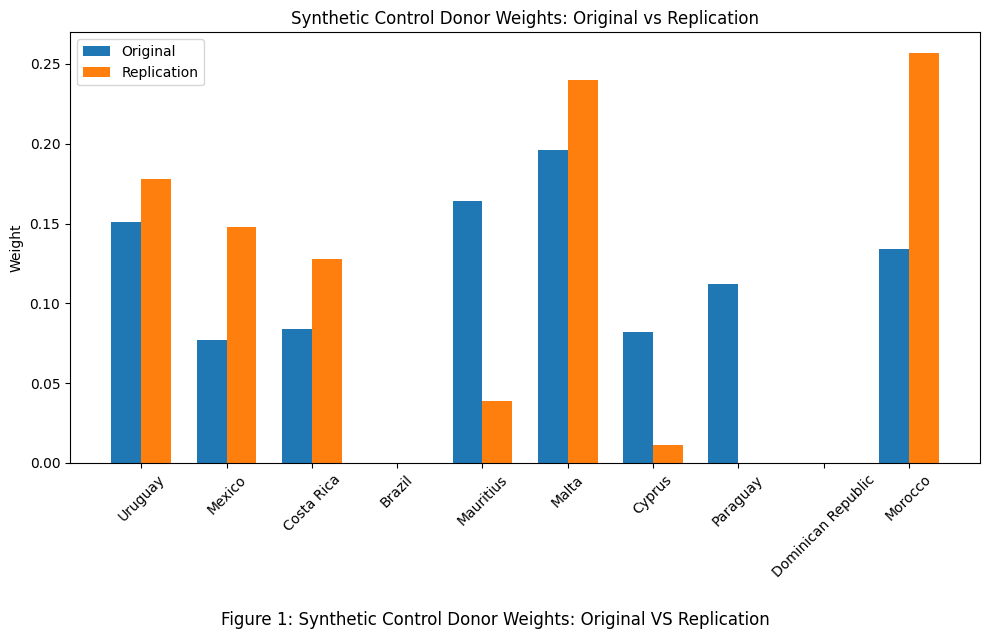

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# estimated weights from pysyncon
rep_weights = donor_weights.copy()
rep_weights.name = "Replication Weight"
rep_weights = rep_weights.reset_index()
rep_weights.columns = ["country", "Replication Weight"]

# Paper's reported weights
paper_weights = pd.DataFrame({
    "country": [
        "Uruguay","Mexico","Costa Rica","Brazil","Mauritius",
        "Malta","Cyprus","Paraguay","Dominican Republic","Morocco"
    ],
    "original_weight": [
        0.151,0.077,0.084,0.000,0.164,
        0.196,0.082,0.112,0.000,0.134
    ]
})

# Merge the two sets of weights
weight_comparison = paper_weights.merge(rep_weights, on="country", how="left")

# Fill missing values (Brazil is absent in our model)
weight_comparison["Replication Weight"] = weight_comparison["Replication Weight"].fillna(0)

weight_comparison


# Create side-by-side bar chart
x = np.arange(len(weight_comparison["country"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, weight_comparison["original_weight"], width, label="Original")
ax.bar(x + width/2, weight_comparison["Replication Weight"], width, label="Replication")

ax.set_xticks(x)
ax.set_xticklabels(weight_comparison["country"], rotation=45)

ax.set_ylabel("Weight")
ax.set_title("Synthetic Control Donor Weights: Original vs Replication")

ax.legend()

plt.tight_layout()

plt.figtext(
    0.5,
    -0.05,
    "Figure 1: Synthetic Control Donor Weights: Original VS Replication",
    ha="center",
    fontsize=12
)
plt.show()

# Comparison of Replication Donor Weights and Original Donor Weights:
Now I can compare the donor weights reported in the original study with the ones from my replication. Although the exact values differ, the overall structure is somewhat similar. In both cases, the synthetic control is driven primarily by Morocco, Malta, Uruguay, Mexico, and Costa Rica, suggesting that the replication identifies a fairly similar set of comparable countries.

However, my replication redistributes weight more heavily toward Morocco, Malta, and Mexico, while assigning less weight to Mauritius, Cyprus, and Paraguay. One potential reason is that Brazil was excluded prior to estimation because one of the predictor variables was missing in the reconstructed dataset. Although the original paper also assigned Brazil a weight of zero, removing it from the optimization still changes the feasible set of donor combinations and can shift weight toward the remaining countries.

Another potential difference is how the variables were manipulated/extracted from the datasets. In the replication, the predictor set was reconstructed from the same sources listed by the authors but any small difference in how they are implemented can still affect the final weights. For example, the investment variable is represented using two separate period-specific measures rather than a single continuous annual series, and the exact handling of those windows can influence which donor countries appear most similar to Colombia. By treating each distinct period as a separate predictor variable, I thus placed more emphasis on investment when determining weights (because there were 2 predictors representing investments), however, it's unclear if the original paper treated the investment variable the same way. Likewise, even when using the same source data, choices about averaging periods, treatment of missing observations, or alignment across merged datasets can slightly alter the predictor matrix and lead to different weight.

Additionally, the computational approach I used to estimate the synthetic control weights was slightly different. The original study was implemented using the Stata synth package developed by Abadie, Diamond, and Hainmueller, but I used the Python package 'pysyncon' (I tried several others but this was the closest and only one that worked). Although both approaches implement the same synthetic control optimization framework, they rely on different numerical solvers and internal calcuations for estimating the predictor weights and donor weights. Small differences in optimization algorithms, convergence tolerances, or other procedures can lead to different weight allocations across donor countries, even when the underlying predictor data are very nearly identical.

# Synthetic Control Donor Weights: Original VS Replication Figure

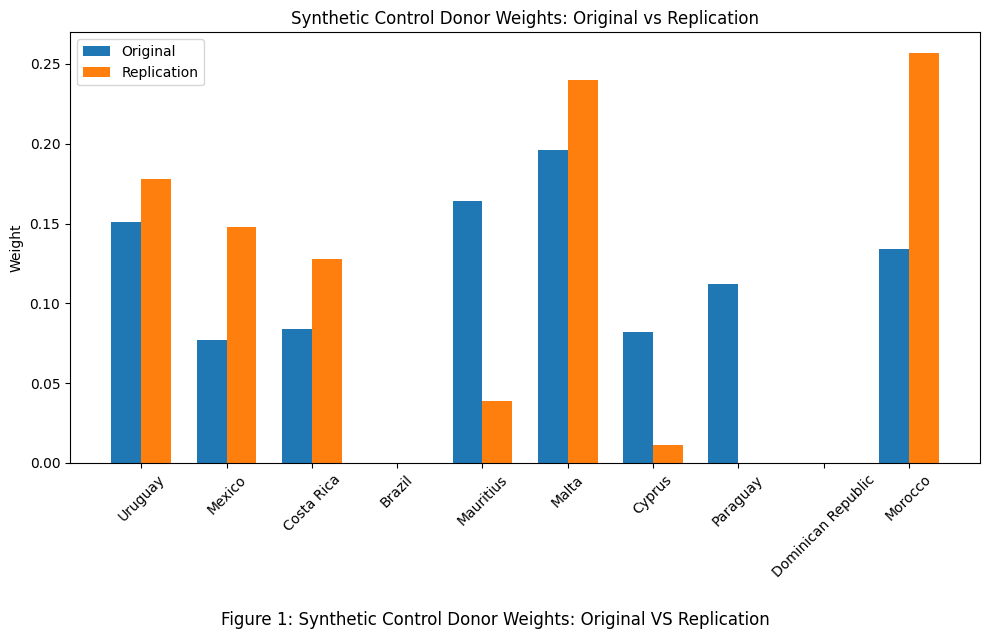

# Synthetic GDP Trajectory for Colombia
Now that the donor weights have been estimated, I can use them to construct the synthetic GDP trajectory for Colombia. I apply the weights from the synthetic control model to the annual GDP per capita series of the donor countries, producing a weighted average that represents the counterfactual path Colombia might have followed in the absence of escalating cartel violence.

The synthetic series is then compared directly to Colombia’s observed GDP per capita over time. A close match before 1976 indicates that the model successfully reproduces Colombia’s pre-treatment trajectory. Any divergence after 1976 can then be interpreted as evidence of the economic cost associated with the treatment period.

In [14]:
%who_ls

['Dataprep',
 'Synth',
 'X0',
 'X1',
 'Z0',
 'Z1',
 'agricultural_tfp_analysis',
 'agricultural_tfp_data',
 'agricultural_tfp_predictor',
 'aligned_middle_income_countries',
 'analysis_panel',
 'appendix_countries',
 'appendix_screening',
 'ax',
 'countries_of_interest',
 'dataprep',
 'donor_countries',
 'donor_units',
 'donor_weights',
 'extra_countries',
 'fig',
 'final_donor_pool',
 'gdp_1975',
 'gdp_long',
 'gdp_panel',
 'gdp_panel_final',
 'gdp_predictor',
 'human_capital_predictor',
 'human_capital_row',
 'inflation_analysis',
 'inflation_data',
 'inflation_pre_treatment',
 'inflation_predictor',
 'inflation_row',
 'investment_1960_1965',
 'investment_1970_1975',
 'investment_analysis',
 'investment_columns',
 'investment_data',
 'maddison_data',
 'middle_income_countries',
 'np',
 'paper_weights',
 'pd',
 'plt',
 'pre_treatment_period',
 'pre_treatment_years',
 'predictor_matrix',
 'predictor_matrix_final',
 'predictor_names',
 'predictor_table',
 'pwt_analysis',
 'pwt_data',
 '

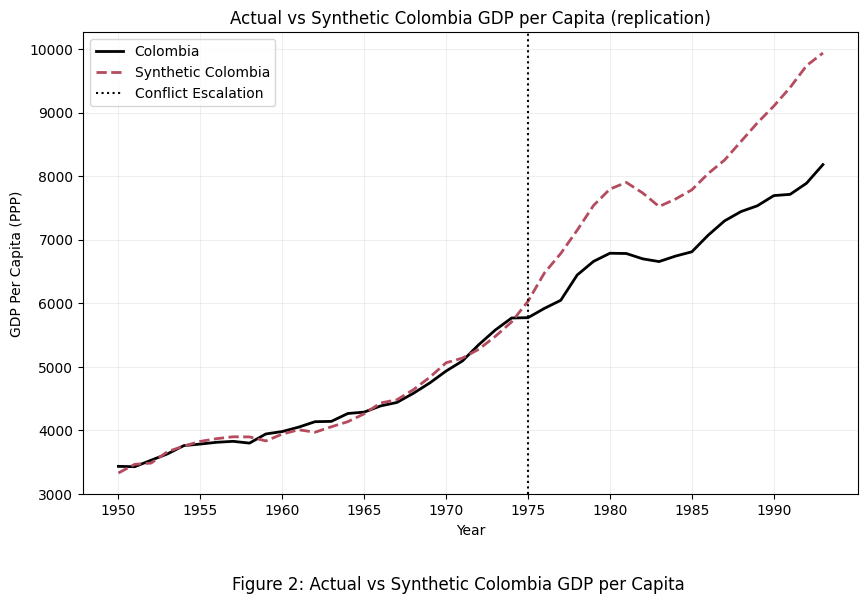

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct the synthetic GDP series using the donor weights
synthetic_gdp_series = gdp_panel_final[donor_weights.index] @ donor_weights

# Combine actual and synthetic Colombia GDP per capita into one DataFrame
gdp_comparison = pd.DataFrame({
    "Actual Colombia": gdp_panel_final["Colombia"],
    "Synthetic Colombia": synthetic_gdp_series
})

gdp_comparison.head()

plt.figure(figsize=(10,6))

# Actual Colombia
plt.plot(
    gdp_comparison.index,
    gdp_comparison["Actual Colombia"],
    color="black",
    linewidth=2,
    label="Colombia"
)

# Synthetic Colombia
plt.plot(
    gdp_comparison.index,
    gdp_comparison["Synthetic Colombia"],
    linestyle="--",
    color="#b54b5e",
    linewidth=2,
    label="Synthetic Colombia"
)

# Treatment year (match original paper: 1975)
plt.axvline(
    x=1975,
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="Conflict Escalation"
)

# X-axis ticks every 5 years
years = np.arange(1950, 1995, 5)
plt.xticks(years)

# Labels
plt.xlabel("Year")
plt.ylabel("GDP Per Capita (PPP)")
plt.title("Actual vs Synthetic Colombia GDP per Capita (replication)")

# Legend
plt.legend()

plt.grid(alpha=0.2)
plt.figtext(
    0.5,
    -0.05,
    "Figure 2: Actual vs Synthetic Colombia GDP per Capita",
    ha="center",
    fontsize=12
)
plt.show()


# Actual vs Synthetic Colombia GDP per Capita

The figure above compares Colombia’s observed GDP per capita with the synthetic counterfactual constructed from the weaighted combination of donor countries. The two datasets closely match up during the pre-treatment period (1950–1975), indicating that the synthetic control successfully reproduces Colombia’s economic trajectory before the escalation of cartel violence. This suggests that the donor weights and predictor variables capture the main determinants of Colombia’s pre-1976 economic growth. After 1976 the two datasets (or "countries") begin to separate, with synthetic Colombia growing more rapidly than the observed series, consistent with the pattern reported in the original study. Below is a direct comparison of my replication figure compared to the original study's figure,demonstrating they both appear to similarly track Colombia prior to the intervention period and display the same trends.

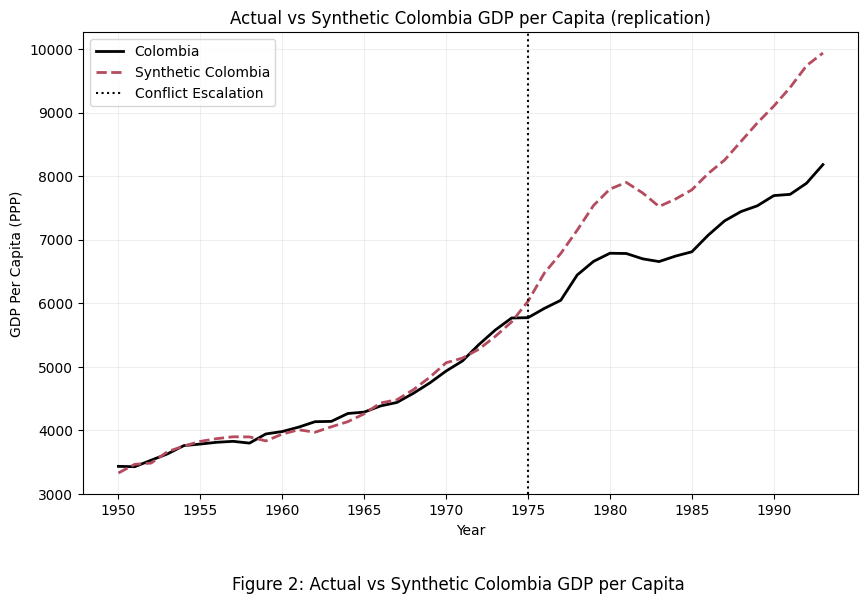

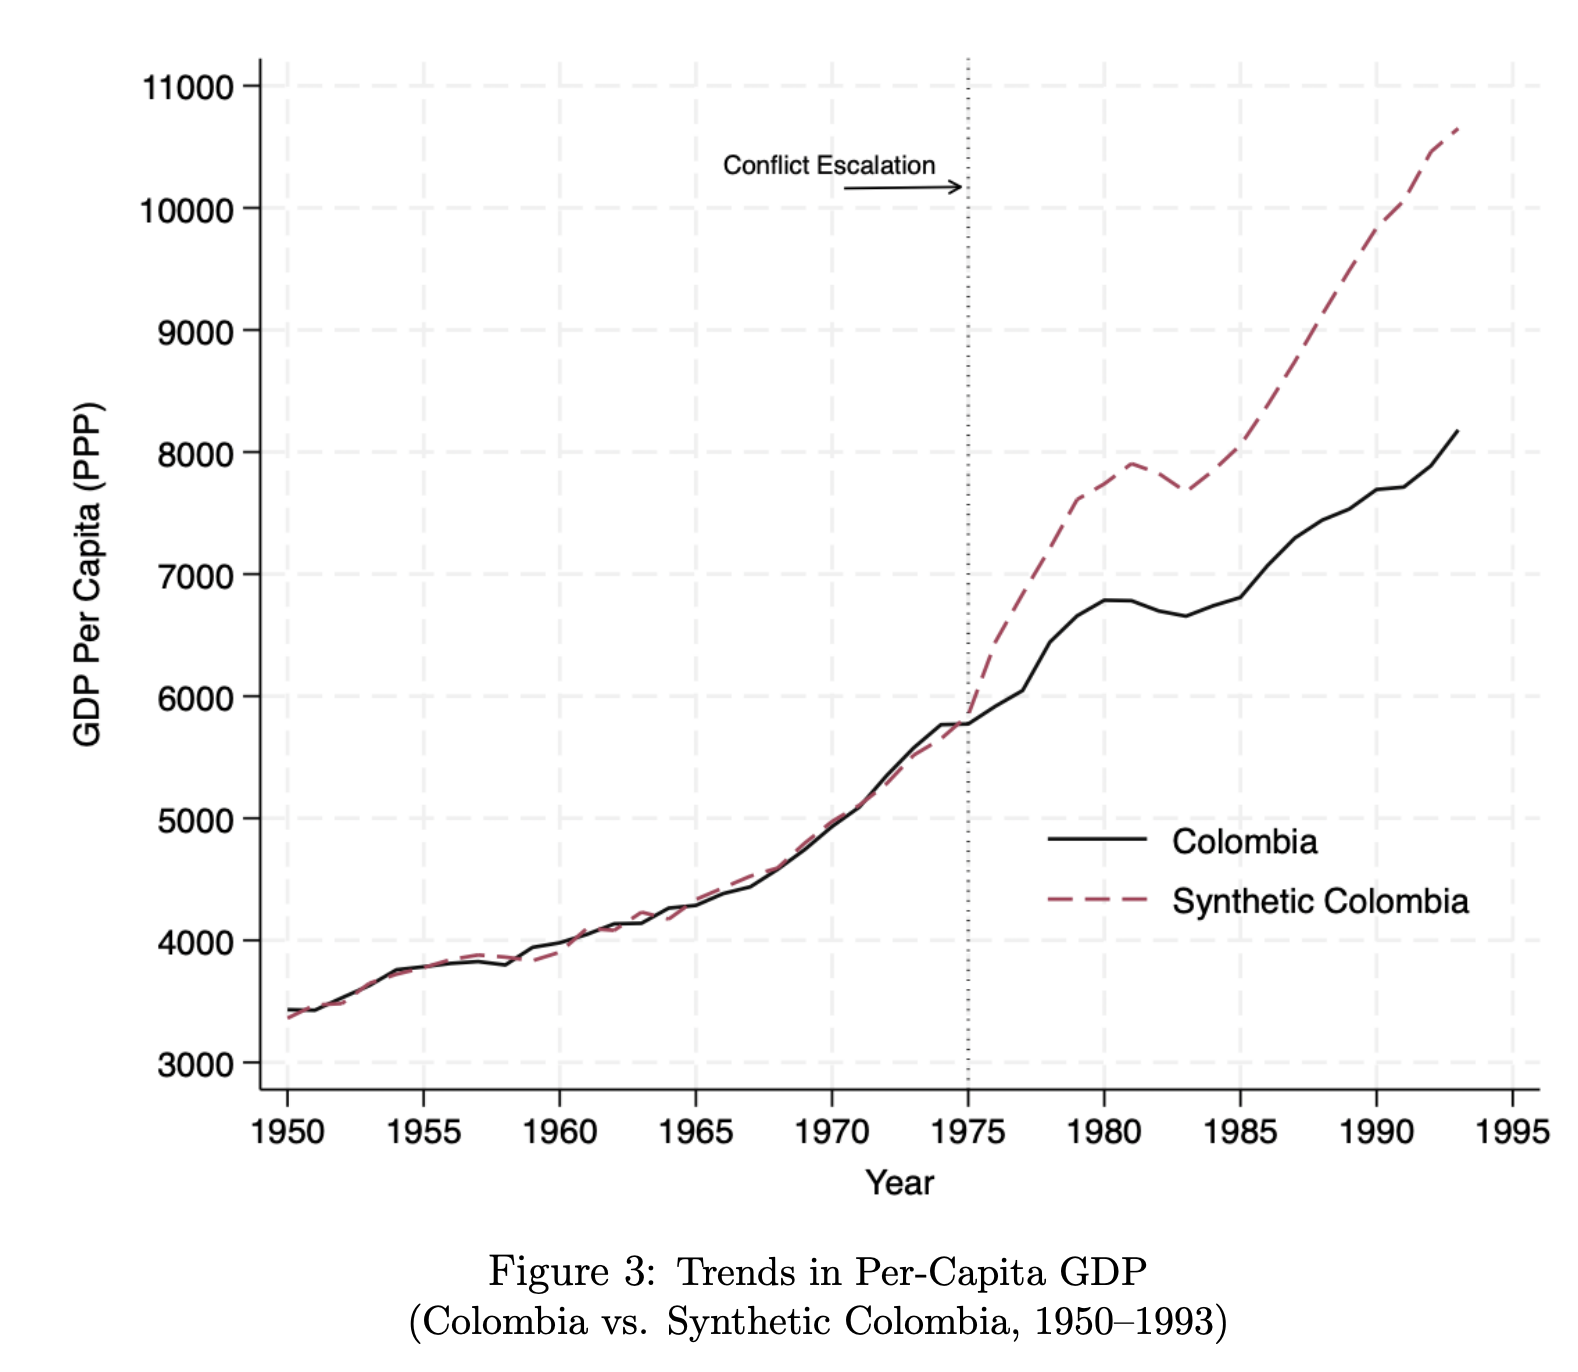


# Annual Per-Capita GDP Gap

After building the synthetic GDP trajectory, the treatment effect can be expressed as the annual gap between Colombia’s observed GDP per capita and the synthetic Colombia's predicted GDP per capita. This difference indicates how far Colombia’s economy fell below the level predicted by the synthetic control after conflict escalation. Negative values imply that observed GDP per capita was lower than the counterfactual, consistent with an economic cost associated with the treatment period.

Plotting the gap also makes it easier to see when the synthetic and actual Colombia begin to distance themselves and how it changes over time.

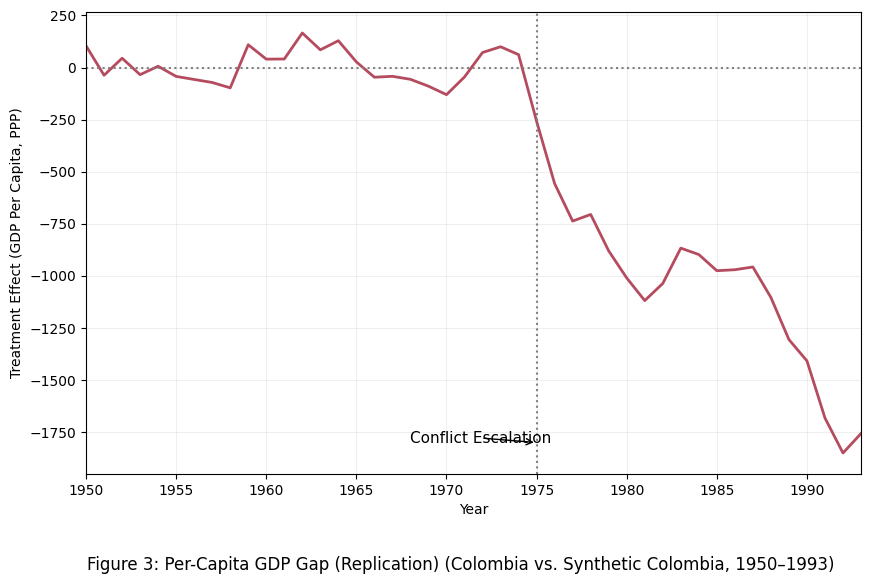

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate GDP gap between observed and synthetic Colombia
gdp_gap = gdp_comparison["Actual Colombia"] - gdp_comparison["Synthetic Colombia"]

gdp_gap.head()

plt.figure(figsize=(10,6))

# Plot the estimated treatment effect (GDP gap)
# This is calculated as Actual Colombia GDP per capita minus Synthetic Colombia GDP per capita
plt.plot(
    gdp_gap.index,
    gdp_gap,
    color="#b54b5e",
    linewidth=2
)

# Vertical dotted line marking the escalation of cartel violence
# The original paper places this boundary at 1975
plt.axvline(
    1975,
    linestyle=":",
    color="gray",
    linewidth=1.5
)

# Horizontal dotted line at zero
# This represents the counterfactual scenario where Colombia perfectly matches the synthetic control
plt.axhline(
    0,
    linestyle=":",
    color="gray",
    linewidth=1.5
)

# X-axis ticks every five years to match the original figure formatting
plt.xticks(np.arange(1950, 1995, 5))
plt.xlim(1950, 1993)

# Axis labels consistent with the paper
plt.xlabel("Year")
plt.ylabel("Treatment Effect (GDP Per Capita, PPP)")

# Annotation used in the original figure to highlight the treatment period
plt.annotate(
    "Conflict Escalation",
    xy=(1975, -1800),
    xytext=(1968, -1800),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

# Light grid to improve readability without overpowering the plot
plt.grid(True, alpha=0.2)

plt.figtext(
    0.5,
    -0.05,
    "Figure 3: Per-Capita GDP Gap (Replication) (Colombia vs. Synthetic Colombia, 1950–1993)",
    ha="center",
    fontsize=12
)

plt.show()

# Per-Capita GDP Gap Comparison Between Replication and Original

The figure above plots the estimated treatment effect, defined as the difference between Colombia’s observed GDP per capita and the synthetic counterfactual made from the donor countries. During the pre-treatment period (1950–1975) the gap fluctuates around zero, indicating that the synthetic control closely reproduces Colombia’s economic trajectory prior to the escalation of cartel violence.

Following 1975 the gap becomes sharply negative, indicating that Colombia’s observed GDP per capita falls below the level predicted by the synthetic control. The difference grows through the late 1970s and 1980s, eventually reaching a difference of more than $1,500 per capita by the early 1990s.

Overall, my replication reproduces the main takeway of the original paper that Colombia’s economic performance diverges substantially from its synthetic comparison after the mid-1970s, suggesting a drastic long term economic cost associated with the conflict period. Below is a comparison of my replication figure and the original figure from the paper, demonstrating the same trends are recapitulated in the replication attempt.


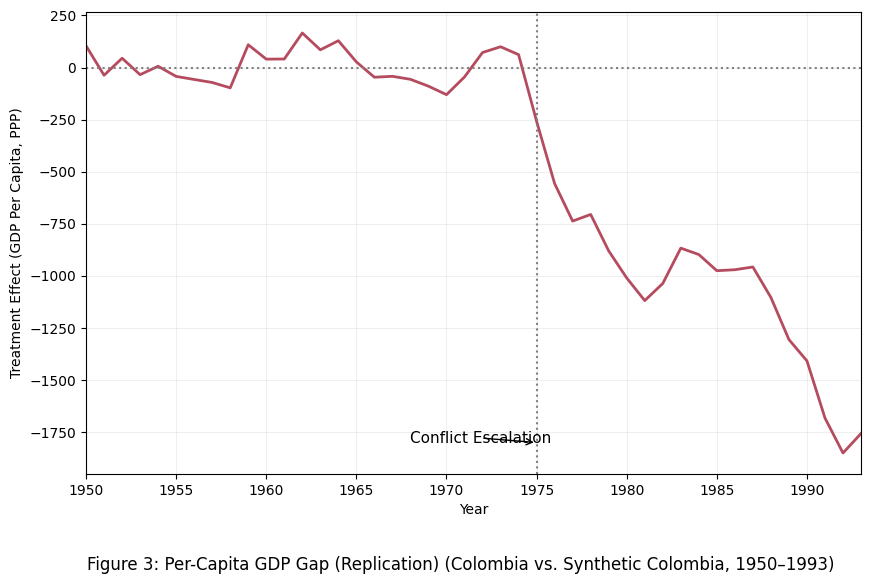


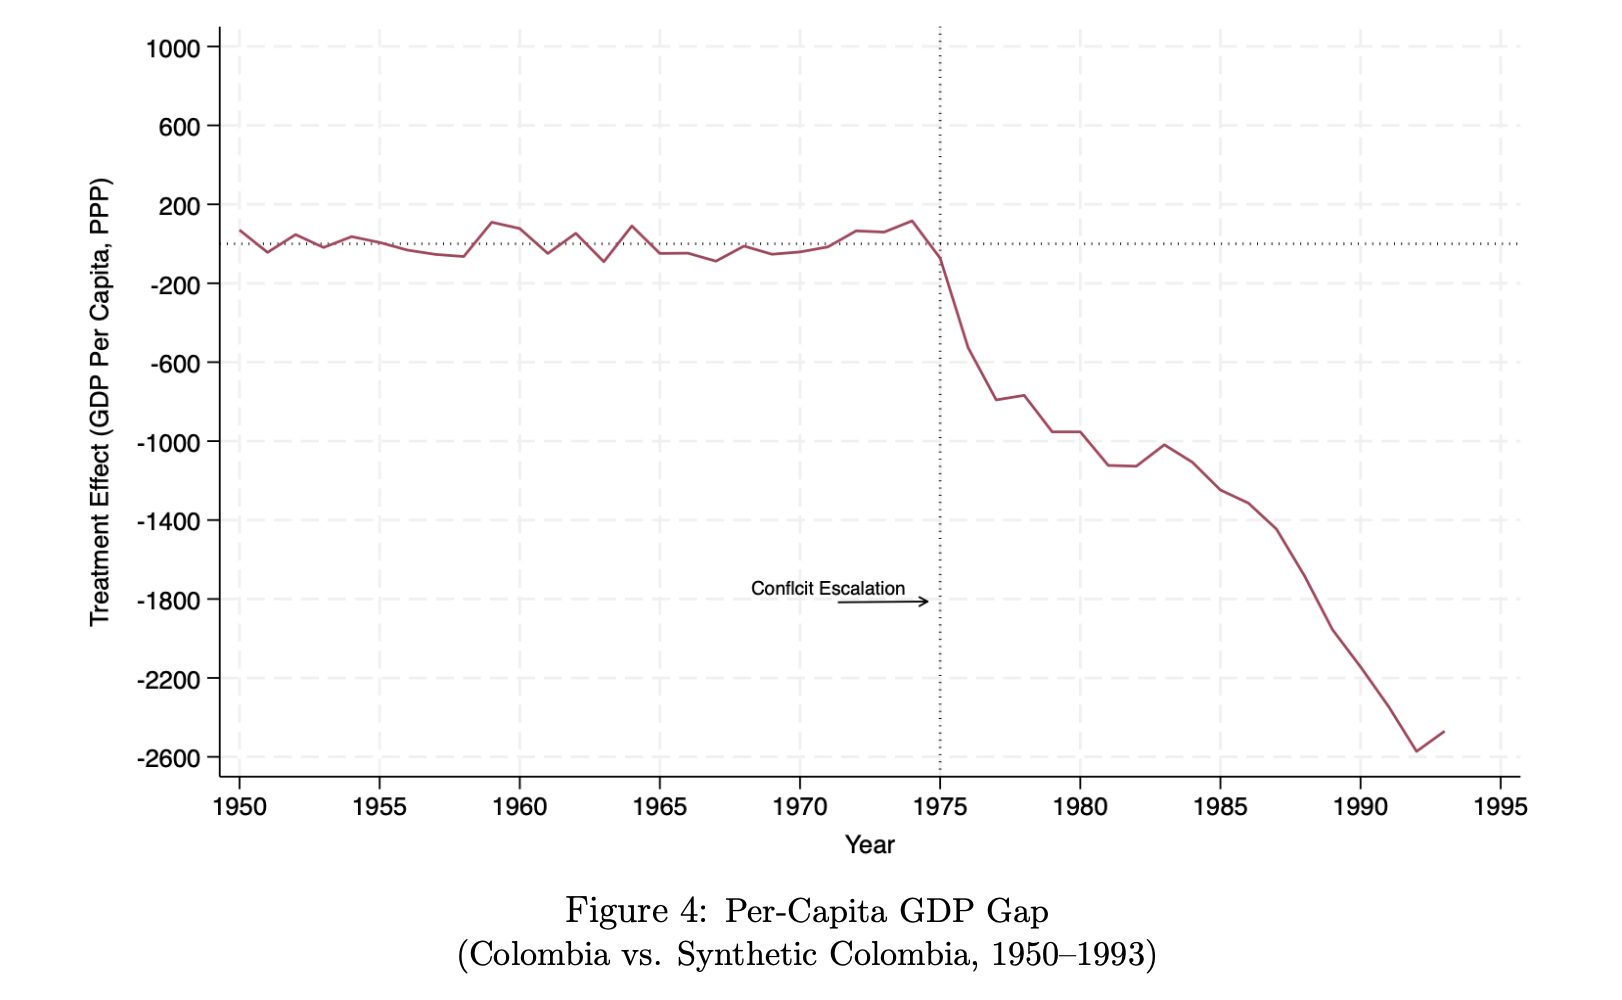

# Accumulated GDP Loss

Although the annual GDP gap shows how the treatment effect changes over time, it is also useful to summarize the total economic impact across the full post-treatment period. To do this, I calculate the cumulative GDP loss per person by summing the yearly differences between Colombia’s observed GDP per capita and the synthetic counterfactual from 1976 to 1993.

Because the gap is observed minus synthetic GDP, the post-treatment values are mostly negative. Taking the negative of this sum converts the result into a cleaner measure of loss, expressed as the total amount of GDP per capita Colombia appears to have lost over the post-1975 period relative to its synthetic control.

In [17]:
# Reuse the estimated GDP gap between observed Colombia and synthetic Colombia
# Negative values mean Colombia's observed GDP per capita fell below the counterfactual
gdp_gap = gdp_comparison["Actual Colombia"] - gdp_comparison["Synthetic Colombia"]

# Keep only the post-treatment years
post_treatment_gap = gdp_gap.loc[1976:1993]

# Sum the yearly post-treatment gaps to measure the cumulative effect over the full treatment period.
cumulative_gap = post_treatment_gap.sum()

# Convert the negative gap into a positive "loss per person" measure for easier interpretation.
cumulative_loss_per_person = -cumulative_gap

print(f"Cumulative GDP loss per person, 1976–1993: ${cumulative_loss_per_person:,.2f}")

Cumulative GDP loss per person, 1976–1993: $19,817.70


# Conclusion
My replication produces results that are consistent with the qualitative findings of the original study, while also containing some differences that can be explained by methodological choices.

First, the donor weights estimated in this replication differ somewhat from those reported in the original paper. In both cases, however, the synthetic control is primarily constructed from a similar group of countries, including Morocco, Malta, Uruguay, Mexico, and Costa Rica. The main difference is in how the weights are distributed across these donors. For example, the replication assigns relatively larger weights to Morocco and Malta while placing no weight on Paraguay and the Dominican Republic. In the original study, Paraguay receives a modest positive weight and Brazil appears in the donor pool but ultimately receives a weight of zero. In this replication Brazil was removed prior to estimation because one of the predictor variables was missing in the reconstructed dataset. Although Brazil’s original weight was zero, removing it changes the feasible optimization space and can slightly redistribute weights among the remaining donors.

These differences in donor weights influence the construction of the synthetic GDP trajectory. Despite the variation in weights, the resulting Actual vs. Synthetic Colombia GDP per capita graph closely resembles the pattern reported in the paper. In both cases the synthetic set tracks Colombia’s observed GDP very closely during the pre-treatment period (1950–1975), suggesting that the synthetic control successfully reproduces Colombia’s economic trajectory prior to the escalation of cartel violence. After 1975, both the original study and my replication show a clear separation between the two datsets, with synthetic Colombia growing more rapidly than the observed data.

The GDP gap figure also recapitulates the pattern reported in the original study. In both cases the gap remains close to zero before the treatment period and becomes increasingly negative afterward, indicating that Colombia’s economy underperformed relative to the synthetic trajectory following the rise of narcotrafficking conflict.

The cumulative GDP loss per capita calculated in my replication is similar in magnitude to the estimate reported in the original paper, although the exact value is different ($19,817 vs $25,542). These differences likely arise from small variations in the predictor matrix construction, the handling of investment variables across two time windows, the exclusion of Brazil due to missing data, and the use of the Python "pysyncon" package instead of the Stata "synth" package used in the original analysis. Because synthetic control weights are estimated through numerical optimization, small changes in implementation can lead to differences in weight allocation and cumulative loss estimates while still producing very similar overall economic trajectories.

My replication reproduces the main finding of the original study that Colombia’s GDP per capita declines substantially from its synthetic counterfactual after the mid-1970s, indicating the cartel violence had a negative long term impact on Colombia's GDP.  